# PE7 mouse multiplexed editing coverage

**Kexin Dong**
**Apr 27, 2026**

This notebook quantifies cancer-associated mutation combinations amenable to modeling by PE7 multiplexed prime editing.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import seaborn as sns
import warnings
import os 
from pegg import prime
import matplotlib.patheffects as PathEffects
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
import re
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['text.usetex'] = False
from scipy.stats import combine_pvalues

yellows = sns.color_palette('Oranges').as_hex()
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
purples = sns.color_palette('Purples').as_hex()

## Overview and Rationale
The aim of this analysis is to show that our PE7 mouse model is a strong tool and has advantages in expanding the spectrum of cancer driver mutation combinations that we can model compared to traditional mouse models.

We will first use the MSK-IMPACT subset of AACR-GENIE data (we probably don't need an extremely large cohort — PEGG guide generation takes time to run and we don't want that to take forever; a reasonably sized pan-cancer cohort will be sufficient). We will retrieve a list of top 2 and top 3 high-VAF driver mutations from each patient in the cohort, generating a list of dual- and triple-mutation combinations that we would be interested in modeling in mice. We then refer to H2M Database v1 to convert them to mouse allele information to facilitate downstream analysis.

We will then look at how traditional mouse models, as well as all possible breeding efforts across them, help us cover these combinations. We will use the MMRRC database to get a list of available mouse models, and assess possible breeding by enumerating all possible combinations of any allele that we have ever had a mouse model for.

On the other hand, we quantify how many of these dual- and triple-mutation combinations can be modeled by PE7 multiplexed prime editing. There is no theoretical limit on the number or combination of mutations for multiplexed PE7 editing. As a result, whatever mutation we can design a pegRNA for via PEGG can be modeled as part of a mutational combination.

We compare and quantify these in a bar plot.

A potential issue to consider is whether to analyze mutations at the amino acid change level or the DNA change level.

## Data Sources
- AACR-GENIE
- MMRRC: www.mmrrc.org/
- PEGG pipeline: https://www.nature.com/articles/s41587-024-02172-9
- H2M: https://www.nature.com/articles/s41587-025-02925-0

## Step 1: Retrieve mutational information from AACR-GENIE data

In [ ]:
# stay consistent with H2M Database
df_mutation_aacr = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v15.0/data_mutations_extended.txt',
                          header=0, sep='\t', comment="#", 
                          na_values=['Not Applicable', 'NA', 'NULL', '-', 'None', ''])
df_pts = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v15.0/data_clinical_patient.txt', header=0, sep='\t', comment="#", na_values = 'Not Applicable')
df_sample = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/AACR-GENIE/v15.0/data_clinical_sample.txt', header=0, sep='\t', comment="#", na_values = 'Not Applicable')

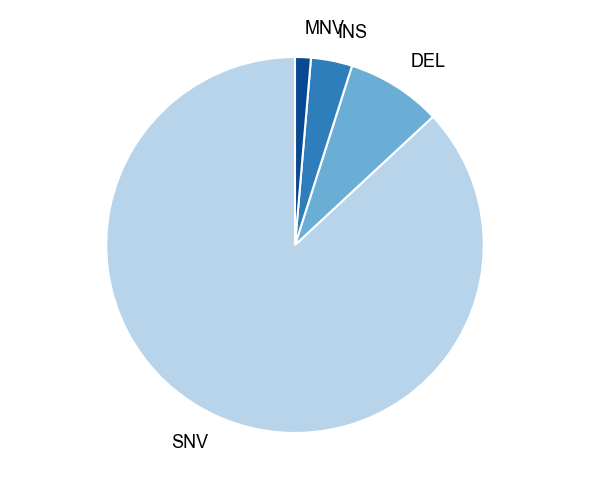

                Count
Variant_Type         
SNV           1600233
DEL            150166
INS             65031
MNV             24881


In [147]:
# Pie plot: distribution of mutation types (Variant_Type)
variant_counts = df_mutation_aacr['Variant_Type'].value_counts()

# merge multi-nucleotide variants; rename SNP -> SNV
mnp_total = variant_counts.reindex(['DNP', 'ONP', 'TNP']).sum()
variant_counts_merged = variant_counts.drop(['DNP', 'ONP', 'TNP'], errors='ignore')
variant_counts_merged['MNV'] = mnp_total
variant_counts_merged.index = variant_counts_merged.index.str.replace('SNP', 'SNV')
variant_counts_merged = variant_counts_merged.sort_values(ascending=False)

n = len(variant_counts_merged)
cmap = plt.cm.Blues
colors = [cmap(0.3 + 0.6 * i / (n - 1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(6, 5))
ax.axis('equal')
wedges, texts = ax.pie(
    variant_counts_merged.values,
    labels=variant_counts_merged.index,
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    labeldistance=1.15,
)
for t in texts:
    t.set_fontsize(13)
plt.setp(wedges, edgecolor='white')
fig.tight_layout()
plt.savefig('figures/variant_type_pie.pdf', bbox_inches='tight')
plt.show()
print(variant_counts_merged.to_frame('Count'))


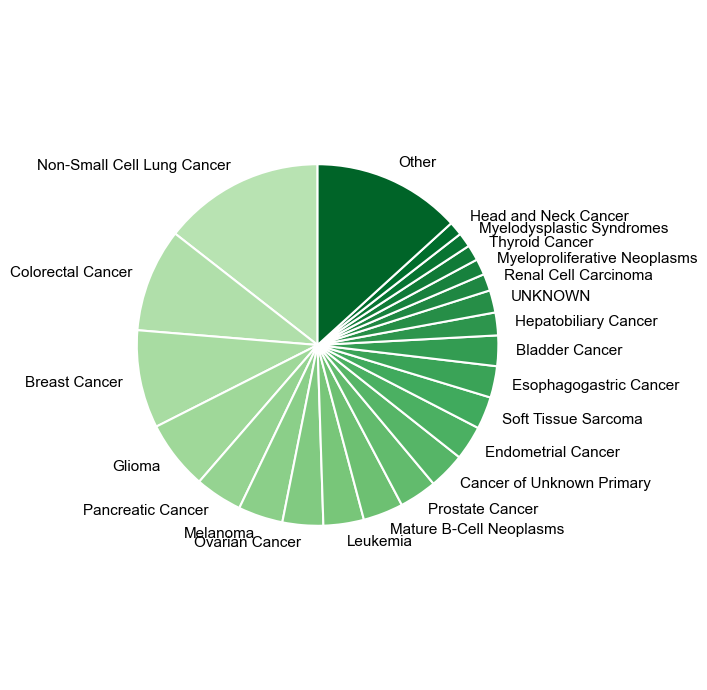

                              Count
CANCER_TYPE                        
Non-Small Cell Lung Cancer    28591
Colorectal Cancer             18334
Breast Cancer                 17351
Glioma                        12250
Pancreatic Cancer              8386
Melanoma                       7918
Ovarian Cancer                 7208
Leukemia                       7157
Mature B-Cell Neoplasms        7107
Prostate Cancer                6666
Cancer of Unknown Primary      6455
Endometrial Cancer             6080
Soft Tissue Sarcoma            5735
Esophagogastric Cancer         5574
Bladder Cancer                 5406
Hepatobiliary Cancer           4032
UNKNOWN                        3960
Renal Cell Carcinoma           2999
Myeloproliferative Neoplasms   2831
Thyroid Cancer                 2778
Myelodysplastic Syndromes      2556
Head and Neck Cancer           2450
Other                         26217


In [146]:

# Pie plot: distribution of cancer types (CANCER_TYPE)
# merge small categories (<1%) into 'Other'
cancer_counts = df_sample['CANCER_TYPE'].value_counts()
threshold = cancer_counts.sum() * 0.01
major = cancer_counts[cancer_counts >= threshold]
other_count = cancer_counts[cancer_counts < threshold].sum()
if other_count > 0:
    major['Other'] = other_count

n = len(major)
cmap = plt.cm.Greens
colors = [cmap(0.3 + 0.6 * i / max(n - 1, 1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(7, 7))
ax.axis('equal')
wedges, texts = ax.pie(
    major.values,
    labels=major.index,
    colors=colors,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
)
for t in texts:
    t.set_fontsize(11)
plt.setp(wedges, edgecolor='white')
fig.tight_layout()
plt.savefig('figures/cancer_type_pie.pdf', bbox_inches='tight')
plt.show()
print(major.to_frame('Count'))


In [151]:
df_mutation_aacr

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,FILTER,Polyphen_Prediction,Polyphen_Score,SIFT_Prediction,SIFT_Score,SWISSPROT,n_depth,t_depth,Annotation_Status,mutationInCis_Flag
0,KRAS,3845.0,JHU,GRCh37,12,25398285,25398285,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,0.991,deleterious,0.04,NaN,NaN,1623.0,SUCCESS,False
1,BRAF,673.0,JHU,GRCh37,7,140453136,140453136,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,0.963,deleterious,0.00,NaN,NaN,1031.0,SUCCESS,False
2,EGFR,1956.0,JHU,GRCh37,7,55249071,55249071,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,1.000,deleterious,0.00,NaN,NaN,692.0,SUCCESS,False
3,TP53,7157.0,JHU,GRCh37,17,7577120,7577120,+,missense_variant,Missense_Mutation,...,PASS,possibly_damaging,0.643,tolerated,0.13,NaN,NaN,930.0,SUCCESS,False
4,NRAS,4893.0,JHU,GRCh37,1,115256529,115256529,+,missense_variant,Missense_Mutation,...,PASS,benign,0.251,tolerated,0.06,NaN,NaN,2277.0,SUCCESS,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1840306,PHF6,84295.0,PROV,GRCh37,X,133551330,133551330,+,"splice_region_variant,synonymous_variant",Splice_Region,...,PASS,NaN,NaN,NaN,NaN,NaN,NaN,311.0,SUCCESS,False
1840307,PHF6,84295.0,PROV,GRCh37,X,133559236,133559236,+,missense_variant,Missense_Mutation,...,PASS,probably_damaging,0.988,deleterious,0.00,NaN,NaN,381.0,SUCCESS,False
1840308,PHF6,84295.0,PROV,GRCh37,X,133559255,133559256,+,frameshift_variant,Frame_Shift_Ins,...,PASS,NaN,NaN,NaN,NaN,NaN,NaN,509.0,SUCCESS,False
1840309,PHF6,84295.0,PROV,GRCh37,X,133559302,133559302,+,missense_variant,Missense_Mutation,...,PASS,benign,0.066,deleterious_low_confidence,0.01,NaN,NaN,788.0,SUCCESS,False


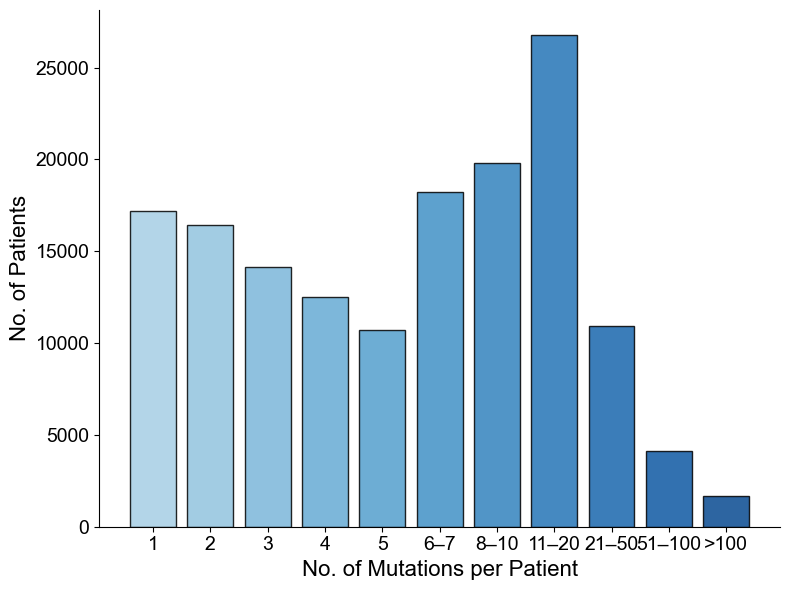

In [145]:
# Bar plot: distribution of number of mutations per patient
muts_per_patient = (
    df_mutation_aacr
    .groupby('Tumor_Sample_Barcode')
    .size()
    .reset_index(name='n_mutations')
    .merge(df_sample[['SAMPLE_ID', 'PATIENT_ID']], left_on='Tumor_Sample_Barcode', right_on='SAMPLE_ID')
    .groupby('PATIENT_ID')['n_mutations'].sum()
)

bins = [0, 1, 2, 3, 4, 5, 7, 10, 20, 50, 100, muts_per_patient.max() + 1]
labels = ['1', '2', '3', '4', '5', '6–7', '8–10', '11–20', '21–50', '51–100', '>100']

binned = pd.cut(muts_per_patient, bins=bins, labels=labels, right=True)
bin_counts = binned.value_counts().reindex(labels)

n = len(bin_counts)
cmap = plt.cm.Blues
colors = [cmap(0.35 + 0.55 * i / (n - 1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(range(n), bin_counts.values, color=colors, edgecolor='black', linewidth=1, alpha=0.85)
ax.set_xticks(range(n))
ax.set_xticklabels(labels, fontsize=14)
ax.set_xlabel('No. of Mutations per Patient', fontsize=16)
ax.set_ylabel('No. of Patients', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.savefig('figures/mutations_per_patient.pdf', bbox_inches='tight')
plt.show()


## Step 2: subset H2M for mouse mutations of these in H2M Database.

In [95]:
# keep mutations ≥ 20 observations in the database
h2m_aacr_input = pd.read_csv('/Users/kexindong/Documents/GitHub/Output/h2m_database/aacr_input.csv')
h2m_aacr_input_over_20 = h2m_aacr_input[h2m_aacr_input['count'] >= 20].reset_index(drop=True)
h2m_aacr_input_over_20

,gene_name_h,tx_id_h,start_h,end_h,ref_seq_h,alt_seq_h,type_h,count,index,gene_name_m,tx_id_m
0,ABL1,ENST00000318560.5,133711046,133711050,CTCTT,-,DEL,297,AACR-H0000129-M01,Abl1,ENSMUST00000075759.13
1,ABL1,ENST00000318560.5,133760617,133760617,C,T,SNP,68,AACR-H0001054-M01,Abl1,ENSMUST00000075759.13
2,ABL1,ENST00000318560.5,133760592,133760592,C,T,SNP,44,AACR-H0001865-M01,Abl1,ENSMUST00000075759.13
3,ABL1,ENST00000318560.5,133759546,133759546,G,A,SNP,43,AACR-H0001915-M01,Abl1,ENSMUST00000075759.13
4,ABL1,ENST00000318560.5,133760024,133760024,C,-,DEL,41,AACR-H0002060-M01,Abl1,ENSMUST00000075759.13
...,...,...,...,...,...,...,...,...,...,...,...
5744,ZRSR2,ENST00000307771.7,15841230,15841231,-,AGCCGG,INS,50,AACR-H0001583-M02,Zrsr2-ps1,ENSMUST00000229075.2
5745,ZRSR2,ENST00000307771.7,15838411,15838411,C,T,SNP,30,AACR-H0003086-M01,Zrsr2,ENSMUST00000112289.9
5746,ZRSR2,ENST00000307771.7,15838411,15838411,C,T,SNP,30,AACR-H0003086-M02,Zrsr2-ps1,ENSMUST00000229075.2
5747,ZSWIM4,ENST00000254323.2,13934296,13934296,A,G,SNP,47,AACR-H0001758-M01,Zswim4,ENSMUST00000039480.7


In [97]:
h2m_aacr_input_over_20 = h2m_aacr_input_over_20.drop_duplicates(subset=['gene_name_h','tx_id_h','start_h','end_h','ref_seq_h','alt_seq_h','type_h','count']).reset_index(drop=True)

In [98]:
df_mutation_aacr_over_20 = df_mutation_aacr.copy()
# manually change some of the symbol names to match H2M Database
dict_of_aacr_symbol = {
    'H3F3A':'H3-3A',
    'H3F3B':'H3-3B',
    'WHSC1':'NSD1',
    'GPR124':'ADGRA2',
    'MKL1':'MRTFA',
    'PARK2':'PRKN',
    'MRE11A':'MRE11',
    'MLLT4':'AFDN',
    'CASC5': 'KNL1',
    'MEF2BNB-MEF2B':'BORCS8-MEF2B',
    'PAK7':'PAK5',
    'HIST1H1C':'H1-2',
    'HIST1H3B': 'H3C1',
    'HIST1H1E': 'H1-4',
    'HIST1H2BD': 'H2BC5',
    'HIST3H3': 'H3-4',
    'HIST1H3D': 'H3C2',
    'HIST1H3E': 'H3C3',
    'HIST1H3J': 'H3C12',
    'HIST1H2BK': 'H2BC8',
    'HIST1H3F': 'H3C4',
    'HIST1H1B': 'H1-5',
    'HIST1H1D': 'H1-3',
    'HIST1H2AC': 'H2AC1',
    'HIST1H2BJ': 'H2BC13',
    'HIST1H4E': 'H4C5',
    'FAM46C':'TENT5C',
    'WHSC1L1':'NSD3',
    'SETD8':'KMT5A',
    'LPHN3':'ADGRL3',
    'BAI3':'ADGRB3',
    'SEPT9':'NAPB',
    'BRE':'BABAM2',
    'RFWD2':'COP1',
    'TCEB1':'ELOC',
    'GBA':'GBA1',
    'PVRL4':'NECTIN4',
    'ICK':'GCKR',
    'GNB2L1':'RACK1',
    'MGEA5':'OGA',
    'DIRC2':'SLC49A4',
    'LARGE':'LARGE1',
    'TMEM173B':'STING1',
    'SEPT5':'SEPTIN5'
    }
df_mutation_aacr_over_20['Hugo_Symbol'] =  [dict_of_aacr_symbol.get(x,x) for x in df_mutation_aacr_over_20['Hugo_Symbol']]
h2m_aacr_input_over_20 = h2m_aacr_input_over_20.rename(columns={'gene_name_h': 'Hugo_Symbol',
                                                                 'start_h': 'Start_Position',
                                                                 'end_h': 'End_Position',
                                                                 'ref_seq_h': 'Reference_Allele',
                                                                 'alt_seq_h': 'Tumor_Seq_Allele2'
                                                                 })

In [99]:
df_mutation_aacr_over_20 = pd.merge(df_mutation_aacr_over_20, h2m_aacr_input_over_20[['Hugo_Symbol', 'Start_Position', 'End_Position', 'Reference_Allele', 'Tumor_Seq_Allele2','index']], on=['Hugo_Symbol', 'Start_Position', 'End_Position', 'Reference_Allele', 'Tumor_Seq_Allele2'], how='inner')

In [100]:
df_mutation_aacr_over_20

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,Polyphen_Prediction,Polyphen_Score,SIFT_Prediction,SIFT_Score,SWISSPROT,n_depth,t_depth,Annotation_Status,mutationInCis_Flag,index
0,KRAS,3845.0,JHU,GRCh37,12,25398285,25398285,+,missense_variant,Missense_Mutation,...,probably_damaging,0.991,deleterious,0.04,NaN,NaN,1623.0,SUCCESS,False,AACR-H0000006-M01
1,BRAF,673.0,JHU,GRCh37,7,140453136,140453136,+,missense_variant,Missense_Mutation,...,probably_damaging,0.963,deleterious,0.00,NaN,NaN,1031.0,SUCCESS,False,AACR-H0000003-M01
2,EGFR,1956.0,JHU,GRCh37,7,55249071,55249071,+,missense_variant,Missense_Mutation,...,probably_damaging,1.000,deleterious,0.00,NaN,NaN,692.0,SUCCESS,False,AACR-H0000053-M01
3,TP53,7157.0,JHU,GRCh37,17,7577120,7577120,+,missense_variant,Missense_Mutation,...,possibly_damaging,0.643,tolerated,0.13,NaN,NaN,930.0,SUCCESS,False,AACR-H0000013-M01
4,NRAS,4893.0,JHU,GRCh37,1,115256529,115256529,+,missense_variant,Missense_Mutation,...,benign,0.251,tolerated,0.06,NaN,NaN,2277.0,SUCCESS,False,AACR-H0000022-M01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317332,BCORL1,63035.0,PROV,GRCh37,X,129149396,129149396,+,missense_variant,Missense_Mutation,...,benign,0.275,NaN,NaN,NaN,NaN,372.0,SUCCESS,False,AACR-H0004720-M01
317333,BCORL1,63035.0,PROV,GRCh37,X,129149660,129149660,+,missense_variant,Missense_Mutation,...,benign,0.009,NaN,NaN,NaN,NaN,1484.0,SUCCESS,False,AACR-H0004163-M01
317334,BCORL1,63035.0,PROV,GRCh37,X,129149660,129149660,+,missense_variant,Missense_Mutation,...,benign,0.009,NaN,NaN,NaN,NaN,1226.0,SUCCESS,False,AACR-H0004163-M01
317335,BCORL1,63035.0,PROV,GRCh37,X,129149660,129149660,+,missense_variant,Missense_Mutation,...,benign,0.009,NaN,NaN,NaN,NaN,1304.0,SUCCESS,False,AACR-H0004163-M01


In [102]:
df_mutation_aacr_over_20 = df_mutation_aacr_over_20.rename(columns={'index': 'h2m_id'})

from itertools import combinations

def get_combos(group, n):
    ids = group['h2m_id'].tolist()
    return list(combinations(ids, n))

# dual combinations
dual = (
    df_mutation_aacr_over_20
    .groupby('Tumor_Sample_Barcode')
    .apply(lambda g: get_combos(g, 2))
    .explode()
    .dropna()
)
dual_df = pd.DataFrame(dual.tolist(), columns=['mut_1', 'mut_2'])
dual_df = dual_df.groupby(['mut_1', 'mut_2']).size().reset_index(name='count').sort_values('count', ascending=False).reset_index(drop=True)
dual_df.index.name = 'rank'

# triple combinations
triple = (
    df_mutation_aacr_over_20
    .groupby('Tumor_Sample_Barcode')
    .apply(lambda g: get_combos(g, 3))
    .explode()
    .dropna()
)
triple_df = pd.DataFrame(triple.tolist(), columns=['mut_1', 'mut_2', 'mut_3'])
triple_df = triple_df.groupby(['mut_1', 'mut_2', 'mut_3']).size().reset_index(name='count').sort_values('count', ascending=False).reset_index(drop=True)
triple_df.index.name = 'rank'

print(dual_df.head(10))
print(triple_df.head(10))


                  mut_1              mut_2  count
rank                                             
0     AACR-H0000122-M01  AACR-H0000123-M01    301
1     AACR-H0000124-M01  AACR-H0000118-M01    301
2     AACR-H0000122-M01  AACR-H0000118-M01    301
3     AACR-H0000123-M01  AACR-H0000118-M01    301
4     AACR-H0000124-M01  AACR-H0000123-M01    301
5     AACR-H0000124-M01  AACR-H0000122-M01    301
6     AACR-H0000128-M01  AACR-H0000124-M01    298
7     AACR-H0000128-M01  AACR-H0000123-M01    298
8     AACR-H0000128-M01  AACR-H0000122-M01    298
9     AACR-H0000128-M01  AACR-H0000118-M01    298
                  mut_1              mut_2              mut_3  count
rank                                                                
0     AACR-H0000124-M01  AACR-H0000123-M01  AACR-H0000118-M01    301
1     AACR-H0000122-M01  AACR-H0000123-M01  AACR-H0000118-M01    301
2     AACR-H0000124-M01  AACR-H0000122-M01  AACR-H0000118-M01    301
3     AACR-H0000124-M01  AACR-H0000122-M01  AACR-H00001

In [103]:
# add gene names from h2m_id lookup
h2m_id_to_gene = df_mutation_aacr_over_20.set_index('h2m_id')['Hugo_Symbol'].to_dict()

dual_df['gene_name_1'] = dual_df['mut_1'].map(h2m_id_to_gene)
dual_df['gene_name_2'] = dual_df['mut_2'].map(h2m_id_to_gene)

triple_df['gene_name_1'] = triple_df['mut_1'].map(h2m_id_to_gene)
triple_df['gene_name_2'] = triple_df['mut_2'].map(h2m_id_to_gene)
triple_df['gene_name_3'] = triple_df['mut_3'].map(h2m_id_to_gene)

print(dual_df.head(10))
print(triple_df.head(10))

                  mut_1              mut_2  count gene_name_1 gene_name_2
rank                                                                     
0     AACR-H0000122-M01  AACR-H0000123-M01    301      PDGFRA        SMC3
1     AACR-H0000124-M01  AACR-H0000118-M01    301        CBLB       SRSF2
2     AACR-H0000122-M01  AACR-H0000118-M01    301      PDGFRA       SRSF2
3     AACR-H0000123-M01  AACR-H0000118-M01    301        SMC3       SRSF2
4     AACR-H0000124-M01  AACR-H0000123-M01    301        CBLB        SMC3
5     AACR-H0000124-M01  AACR-H0000122-M01    301        CBLB      PDGFRA
6     AACR-H0000128-M01  AACR-H0000124-M01    298        CBLB        CBLB
7     AACR-H0000128-M01  AACR-H0000123-M01    298        CBLB        SMC3
8     AACR-H0000128-M01  AACR-H0000122-M01    298        CBLB      PDGFRA
9     AACR-H0000128-M01  AACR-H0000118-M01    298        CBLB       SRSF2
                  mut_1              mut_2              mut_3  count  \
rank                                    

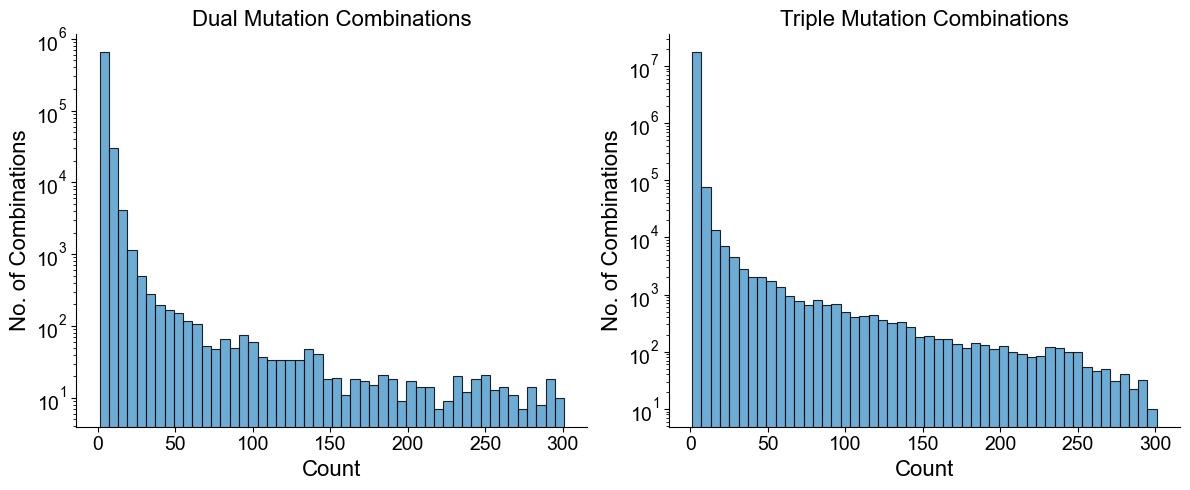

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, title in zip(axes, [dual_df, triple_df], ['Dual Mutation Combinations', 'Triple Mutation Combinations']):
    ax.hist(df['count'], bins=50, color=blues[3], edgecolor='black', linewidth=0.8, alpha=0.85)
    ax.set_xlabel('Count', fontsize=16)
    ax.set_ylabel('No. of Combinations', fontsize=16)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_yscale('log')


fig.tight_layout()
plt.savefig('figures/combo_count_histogram.pdf', bbox_inches='tight')
plt.show()

In [115]:
dual_df_over_50 = dual_df[dual_df['count'] >= 50]
triple_df_over_50 = triple_df[triple_df['count'] >= 50]

In [116]:
n_dual_clinical = len(dual_df_over_50)
n_triple_clinical= len(triple_df_over_50)

In [117]:
n_dual_clinical

1332

In [118]:
n_triple_clinical

12863

In [ ]:
# load the H2M Database result data 
# Supplementary Data 3
h2m = pd.read_csv('/Users/kexindong/Documents/GitHub/Output/h2m_database/database-output-final/df_result_cleaned_v3.csv')

In [137]:
h2m_model_info = h2m[['ID_mouse','status']]
h2m_model_info['ID_mouse'] = h2m_model_info['ID_mouse'].apply(lambda x: '-'.join(x.split('-')[:-1]) if isinstance(x, str) else x)
h2m_model_info

,ID_mouse,status
0,AACR-H0155944-M01,True
1,AACR-H0155944-M02,True
2,AACR-H0614768-M01,True
3,AACR-H0614768-M02,True
4,AACR-H0156000-M01,True
...,...,...
954122,NaN,False
954123,NaN,False
954124,NaN,False
954125,NaN,False


In [130]:
h2m['ID_human']

0         AACR-H0155944
1         AACR-H0155944
2         AACR-H0614768
3         AACR-H0614768
4         AACR-H0156000
              ...      
954122    AACR-H0384675
954123    AACR-H0384676
954124    AACR-H0384703
954125    AACR-H0384704
954126    AACR-H0001786
Name: ID_human, Length: 954127, dtype: object

In [106]:
pegg_h2m_subset = pd.read_csv('/Users/kexindong/Desktop/PhD/H2M/h2m_data/1_murine_mutation_database/PE_Guides.csv')
pegg_h2m_subset

,mutation_idx,Hugo_Symbol,Start_Position,End_Position,Reference_Allele,Tumor_Seq_Allele2,Variant_Type,ID,Chromosome,seq_start,...,RTT_GC_content,indel_size,PEGG2_Score,RF_Score,pegRNA_rank,sensor_wt,sensor_alt,sensor_orientation,sensor_error,contains_polyT_terminator
0,0,CD79B,62006799,62006799,A,G,SNP,AACR-H0002100,17,62006679,...,0.80,0,23.027879,16.035646,1.0,TCAGAGCTGCTGGGCCTGCCCCTCTCCTTACCTCGTAGGTGTGATC...,TCAGAGCTGCTGGGCCTGCCCCTCTCCTTACCTCGTGGGTGTGATC...,reverse-complement,No Error,False
1,0,CD79B,62006799,62006799,A,G,SNP,AACR-H0002100,17,62006679,...,0.80,0,19.778981,13.473911,2.0,TGACAGCAAGGCTGGCATGGAGGAAGATCACACCTACGAGGTAAGG...,TGACAGCAAGGCTGGCATGGAGGAAGATCACACCCACGAGGTAAGG...,reverse-complement,No Error,False
2,0,CD79B,62006799,62006799,A,G,SNP,AACR-H0002100,17,62006679,...,0.80,0,19.567352,13.473911,3.0,TGACAGCAAGGCTGGCATGGAGGAAGATCACACCTACGAGGTAAGG...,TGACAGCAAGGCTGGCATGGAGGAAGATCACACCCACGAGGTAAGG...,reverse-complement,No Error,False
3,0,CD79B,62006799,62006799,A,G,SNP,AACR-H0002100,17,62006679,...,0.60,0,16.589368,13.266724,4.0,CTCCTTACCTCGTAGGTGTGATCTTCCTCCATGCCAGCCTTGCTGT...,CTCCTTACCTCGTGGGTGTGATCTTCCTCCATGCCAGCCTTGCTGT...,reverse-complement,No Error,False
4,0,CD79B,62006799,62006799,A,G,SNP,AACR-H0002100,17,62006679,...,0.80,0,24.061402,12.680708,5.0,TCAGAGCTGCTGGGCCTGCCCCTCTCCTTACCTCGTAGGTGTGATC...,TCAGAGCTGCTGGGCCTGCCCCTCTCCTTACCTCGTGGGTGTGATC...,reverse-complement,No Error,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48250,4708,Bcl9,97117238,97117238,C,T,SNP,AACR-H0005030-M01-V01,3,97117118,...,0.60,0,17.825962,27.045849,1.0,GAGCACTGCTGGACGACCACCTGCTCCTGTTTCCGCCTCTTCTCTT...,GAGCACTGCTGGACGACCACCTGCTCCTGTTTTCGCCTCTTCTCTT...,reverse-complement,No Error,True
48251,4708,Bcl9,97117238,97117238,C,T,SNP,AACR-H0005030-M01-V01,3,97117118,...,0.52,0,17.151807,21.992069,2.0,GAGTTTTATGAAGAGAAGAGGCGGAAACAGGAGCAGGTGGTCGTCC...,GAGTTTTATGAAGAGAAGAGGCGAAAACAGGAGCAGGTGGTCGTCC...,reverse-complement,No Error,False
48252,4708,Bcl9,97117238,97117238,C,T,SNP,AACR-H0005030-M01-V01,3,97117118,...,0.60,0,17.394716,21.161375,3.0,GAGCACTGCTGGACGACCACCTGCTCCTGTTTCCGCCTCTTCTCTT...,GAGCACTGCTGGACGACCACCTGCTCCTGTTTTCGCCTCTTCTCTT...,reverse-complement,No Error,True
48253,4708,Bcl9,97117238,97117238,C,T,SNP,AACR-H0005030-M01-V01,3,97117118,...,0.50,0,17.173775,19.967213,4.0,GAGTTTTATGAAGAGAAGAGGCGGAAACAGGAGCAGGTGGTCGTCC...,GAGTTTTATGAAGAGAAGAGGCGAAAACAGGAGCAGGTGGTCGTCC...,reverse-complement,No Error,False


In [107]:
pegg_h2m_subset = pegg_h2m_subset[pegg_h2m_subset['contains_polyT_terminator']==False].reset_index(drop=True)
pegg_h2m_subset = pegg_h2m_subset[pegg_h2m_subset['sensor_error']!='sensor too small; increase sensor size in parameters; or decrease before_proto_context'].reset_index(drop=True)
pegg_h2m_subset

,mutation_idx,Hugo_Symbol,Start_Position,End_Position,Reference_Allele,Tumor_Seq_Allele2,Variant_Type,ID,Chromosome,seq_start,...,RTT_GC_content,indel_size,PEGG2_Score,RF_Score,pegRNA_rank,sensor_wt,sensor_alt,sensor_orientation,sensor_error,contains_polyT_terminator
0,0,CD79B,62006799,62006799,A,G,SNP,AACR-H0002100,17,62006679,...,0.80,0,23.027879,16.035646,1.0,TCAGAGCTGCTGGGCCTGCCCCTCTCCTTACCTCGTAGGTGTGATC...,TCAGAGCTGCTGGGCCTGCCCCTCTCCTTACCTCGTGGGTGTGATC...,reverse-complement,No Error,False
1,0,CD79B,62006799,62006799,A,G,SNP,AACR-H0002100,17,62006679,...,0.80,0,19.778981,13.473911,2.0,TGACAGCAAGGCTGGCATGGAGGAAGATCACACCTACGAGGTAAGG...,TGACAGCAAGGCTGGCATGGAGGAAGATCACACCCACGAGGTAAGG...,reverse-complement,No Error,False
2,0,CD79B,62006799,62006799,A,G,SNP,AACR-H0002100,17,62006679,...,0.80,0,19.567352,13.473911,3.0,TGACAGCAAGGCTGGCATGGAGGAAGATCACACCTACGAGGTAAGG...,TGACAGCAAGGCTGGCATGGAGGAAGATCACACCCACGAGGTAAGG...,reverse-complement,No Error,False
3,0,CD79B,62006799,62006799,A,G,SNP,AACR-H0002100,17,62006679,...,0.60,0,16.589368,13.266724,4.0,CTCCTTACCTCGTAGGTGTGATCTTCCTCCATGCCAGCCTTGCTGT...,CTCCTTACCTCGTGGGTGTGATCTTCCTCCATGCCAGCCTTGCTGT...,reverse-complement,No Error,False
4,0,CD79B,62006799,62006799,A,G,SNP,AACR-H0002100,17,62006679,...,0.80,0,24.061402,12.680708,5.0,TCAGAGCTGCTGGGCCTGCCCCTCTCCTTACCTCGTAGGTGTGATC...,TCAGAGCTGCTGGGCCTGCCCCTCTCCTTACCTCGTGGGTGTGATC...,reverse-complement,No Error,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42697,4707,Ep300,81525575,81525576,-,A,INS,AACR-H0005029-M01-V01,15,81525455,...,0.40,1,12.537482,3.845314,3.0,TGCAAGAATGGTACAAAAAGATGCTTGACAAGGCTGTATCAGAACG...,TGCAAGAATGGTACAAAAAAGATGCTTGACAAGGCTGTATCAGAAC...,reverse-complement,No Error,False
42698,4707,Ep300,81525575,81525576,-,A,INS,AACR-H0005029-M01-V01,15,81525455,...,0.40,1,13.204321,3.705436,4.0,TGCAAGAATGGTACAAAAAGATGCTTGACAAGGCTGTATCAGAACG...,TGCAAGAATGGTACAAAAAAGATGCTTGACAAGGCTGTATCAGAAC...,reverse-complement,No Error,False
42699,4708,Bcl9,97117238,97117238,C,T,SNP,AACR-H0005030-M01-V01,3,97117118,...,0.52,0,17.151807,21.992069,2.0,GAGTTTTATGAAGAGAAGAGGCGGAAACAGGAGCAGGTGGTCGTCC...,GAGTTTTATGAAGAGAAGAGGCGAAAACAGGAGCAGGTGGTCGTCC...,reverse-complement,No Error,False
42700,4708,Bcl9,97117238,97117238,C,T,SNP,AACR-H0005030-M01-V01,3,97117118,...,0.50,0,17.173775,19.967213,4.0,GAGTTTTATGAAGAGAAGAGGCGGAAACAGGAGCAGGTGGTCGTCC...,GAGTTTTATGAAGAGAAGAGGCGAAAACAGGAGCAGGTGGTCGTCC...,reverse-complement,No Error,False


In [124]:
list_ids = pegg_h2m_subset['ID'].tolist()
list_ids = ['-'.join(x.split('-')[:-1]) for x in list_ids]

In [125]:
list_ids_set = set(list_ids)

dual_df_over_50['amenable_1'] = dual_df_over_50['mut_1'].isin(list_ids_set)
dual_df_over_50['amenable_2'] = dual_df_over_50['mut_2'].isin(list_ids_set)
dual_df_over_50['both_amenable'] = dual_df_over_50['amenable_1'] & dual_df_over_50['amenable_2']

triple_df_over_50['amenable_1'] = triple_df_over_50['mut_1'].isin(list_ids_set)
triple_df_over_50['amenable_2'] = triple_df_over_50['mut_2'].isin(list_ids_set)
triple_df_over_50['amenable_3'] = triple_df_over_50['mut_3'].isin(list_ids_set)
triple_df_over_50['all_amenable'] = triple_df_over_50['amenable_1'] & triple_df_over_50['amenable_2'] & triple_df_over_50['amenable_3']

In [138]:
h2m_id_to_status = h2m_model_info.set_index('ID_mouse')['status'].to_dict()

dual_df_over_50['mouse_variant_1'] = dual_df_over_50['mut_1'].map(h2m_id_to_status)
dual_df_over_50['mouse_variant_2'] = dual_df_over_50['mut_2'].map(h2m_id_to_status)

triple_df_over_50['mouse_variant_1'] = triple_df_over_50['mut_1'].map(h2m_id_to_status)
triple_df_over_50['mouse_variant_2'] = triple_df_over_50['mut_2'].map(h2m_id_to_status)
triple_df_over_50['mouse_variant_3'] = triple_df_over_50['mut_3'].map(h2m_id_to_status)


In [140]:
# PE amenable
n_dual_amenable = dual_df_over_50['both_amenable'].sum()
n_triple_amenable = triple_df_over_50['all_amenable'].sum()

# traditional mouse model (both/all have a known mouse variant)
dual_df_over_50['both_mouse'] = dual_df_over_50['mouse_variant_1'].notna() & dual_df_over_50['mouse_variant_2'].notna()
triple_df_over_50['all_mouse'] = triple_df_over_50['mouse_variant_1'].notna() & triple_df_over_50['mouse_variant_2'].notna() & triple_df_over_50['mouse_variant_3'].notna()

n_dual_mouse = dual_df_over_50['both_mouse'].sum()
n_triple_mouse = triple_df_over_50['all_mouse'].sum()

# totals
n_dual_total = len(dual_df_over_50)
n_triple_total = len(triple_df_over_50)

print(f'Dual   — Total: {n_dual_total},Mouse model: {n_dual_mouse}, PE amenable: {n_dual_amenable}')
print(f'Triple — Total: {n_triple_total}, Mouse model: {n_triple_mouse}, PE amenable: {n_triple_amenable}')

Dual   — Total: 1332,Mouse model: 563, PE amenable: 488
Triple — Total: 12863, Mouse model: 2972, PE amenable: 2301


In [141]:
dual_df_over_50.to_csv('data/dual_combinations_over_50.csv', index=False)
triple_df_over_50.to_csv('data/triple_combinations_over_50.csv', index=False)

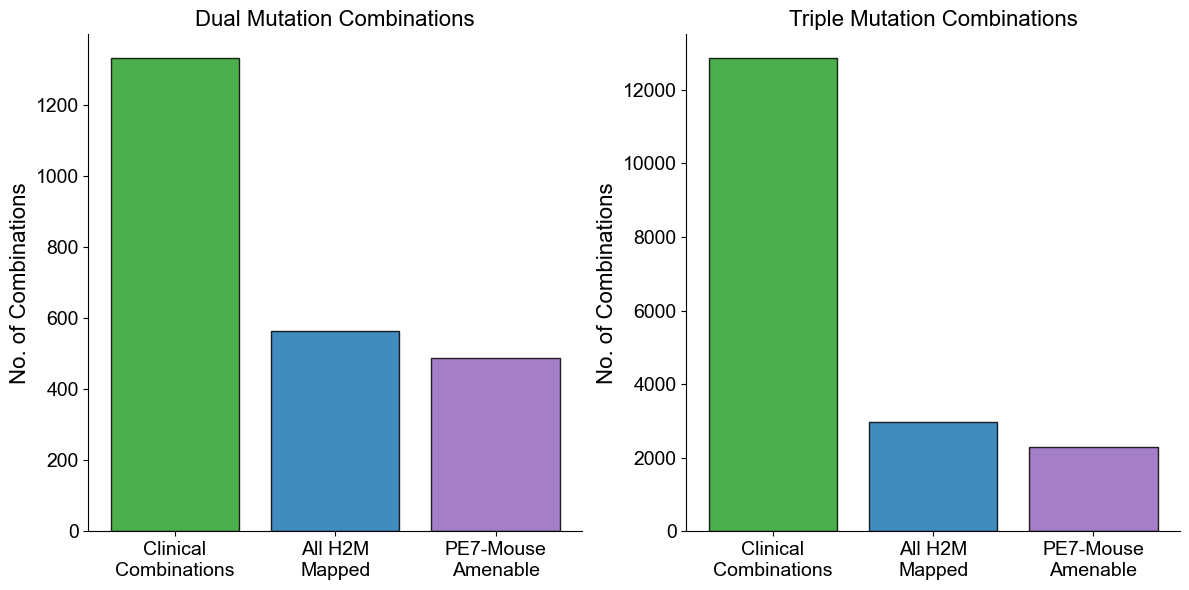

In [143]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

categories = ['Clinical\nCombinations', 'All H2M\nMapped', 'PE7-Mouse\nAmenable']
colors = ['tab:green', 'tab:blue', 'tab:purple']

for ax, total, mouse, amenable, title in zip(
    axes,
    [n_dual_total, n_triple_total],
    [n_dual_mouse, n_triple_mouse],
    [n_dual_amenable, n_triple_amenable],
    ['Dual Mutation Combinations', 'Triple Mutation Combinations']
):
    heights = [total, mouse, amenable]
    ax.bar(range(3), heights, color=colors, edgecolor='black', linewidth=1, alpha=0.85)
    ax.set_xticks(range(3))
    ax.set_xticklabels(categories, fontsize=14)
    ax.set_ylabel('No. of Combinations', fontsize=16)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.savefig('figures/combo_coverage.pdf', bbox_inches='tight')
plt.show()

In [48]:
h2m[['start_h', 'end_h', 'ref_seq_h', 'alt_seq_h']]

,start_h,end_h,ref_seq_h,alt_seq_h
0,87225124,87225124,T,-
1,87225124,87225124,T,-
2,87180117,87180118,CC,TT
3,87180117,87180118,CC,TT
4,87174220,87174221,-,C
...,...,...,...,...
954122,13941133,13941133,C,T
954123,13941242,13941242,C,T
954124,13923938,13923938,C,T
954125,13923971,13923971,C,T


In [47]:
h2m.columns

Index(['gene_name_h', 'gene_id_h', 'tx_id_h', 'chr_h', 'exon_num_h',
       'strand_h', 'match', 'start_h', 'end_h', 'ref_seq_h', 'alt_seq_h',
       'HGVSc_h', 'HGVSp_h', 'classification_h', 'exon_h', 'type_h', 'status',
       'class', 'statement', 'flank_size_left', 'flank_size_right',
       'gene_name_m', 'gene_id_m', 'tx_id_m', 'chr_m', 'exon_num_m',
       'strand_m', 'type_m', 'classification_m', 'exon_m', 'start_m_ori',
       'end_m_ori', 'ref_seq_m_ori', 'alt_seq_m_ori', 'HGVSc_m_ori',
       'HGVSp_m_ori', 'start_m', 'end_m', 'ref_seq_m', 'alt_seq_m', 'HGVSc_m',
       'HGVSp_m', 'ID_human', 'ID_mouse', 'Database', 'ID_db', 'pe_human',
       'pe_mouse', 'be_human', 'be_mouse', 'expanded', 'flank_size'],
      dtype='object')

In [45]:
set(df_mutation_impact)

{'Annotation_Status',
 'BAM_File',
 'Center',
 'Chromosome',
 'Codons',
 'Consequence',
 'End_Position',
 'Entrez_Gene_Id',
 'Exon_Number',
 'FILTER',
 'HGVSc',
 'HGVSp',
 'HGVSp_Short',
 'Hugo_Symbol',
 'Match_Norm_Seq_Allele1',
 'Match_Norm_Seq_Allele2',
 'Match_Norm_Validation_Allele1',
 'Match_Norm_Validation_Allele2',
 'Matched_Norm_Sample_Barcode',
 'Mutation_Status',
 'NCBI_Build',
 'Polyphen_Prediction',
 'Polyphen_Score',
 'Protein_position',
 'RefSeq',
 'Reference_Allele',
 'SIFT_Prediction',
 'SIFT_Score',
 'SWISSPROT',
 'Score',
 'Sequence_Source',
 'Sequencer',
 'Sequencing_Phase',
 'Start_Position',
 'Strand',
 'Transcript_ID',
 'Tumor_Sample_Barcode',
 'Tumor_Seq_Allele1',
 'Tumor_Seq_Allele2',
 'Tumor_Validation_Allele1',
 'Tumor_Validation_Allele2',
 'Validation_Method',
 'Validation_Status',
 'Variant_Classification',
 'Variant_Type',
 'Verification_Status',
 'dbSNP_RS',
 'dbSNP_Val_Status',
 'gnomAD_AF',
 'gnomAD_AFR_AF',
 'gnomAD_AMR_AF',
 'gnomAD_ASJ_AF',
 'gnomAD_

## Traditional Mouse model

In [34]:
mmrrc = pd.read_csv('/Users/kexindong/Documents/GitHub/Database/PublicDatabase/MMRRC/mmrrc_catalog_data.csv')

In [37]:
mmrrc_tm = mmrrc[mmrrc['MUTATION_TYPE']=='TM'].reset_index(drop=True)
mmrrc_tm

,STRAIN/STOCK_ID,STRAIN/STOCK_DESIGNATION,OTHER_NAMES,STRAIN_TYPE,STATE,MGI_ALLELE_ACCESSION_ID,ALLELE_SYMBOL,ALLELE_NAME,MUTATION_TYPE,CHROMOSOME,MGI_GENE_ACCESSION_ID,GENE_SYMBOL,GENE_NAME,SDS_URL,ACCEPTED_DATE,MPT_IDS,PUBMED_IDS,RESEARCH_AREAS
0,MMRRC:000002-UNC,B6.129P2-<i>Esr2<sup>tm1Unc</sup></i>/Mmnc,RRID:MMRRC_000002-UNC,CON,CA,MGI:2152217,Esr2<tm1Unc>,estrogen receptor 2 (beta); targeted mutation ...,TM,12,NaN,NaN,NaN,https://www.mmrrc.org/catalog/sds.php?mmrrc_id=2,04/24/2001,decreased bone mineral density [MP:0000063]| a...,PMID: 9861029,NaN
1,MMRRC:000002-UNC,B6.129P2-<i>Esr2<sup>tm1Unc</sup></i>/Mmnc,RRID:MMRRC_000002-UNC,CON,CA,NaN,NaN,NaN,TM,12,MGI:109392,Esr2,estrogen receptor 2 (beta),https://www.mmrrc.org/catalog/sds.php?mmrrc_id=2,04/24/2001,decreased bone mineral density [MP:0000063]| a...,PMID: 9861029,NaN
2,MMRRC:000011-UCD,STOCK <i>Mecp2<sup>tm1.1Jae</sup></i>/Mmucd,RRID:MMRRC_000011-UCD,MSK,"CA,SP,EM",MGI:2158354,Mecp2<tm1.1Jae>,methyl CpG binding protein 2; targeted mutatio...,TM,X,NaN,NaN,NaN,https://www.mmrrc.org/catalog/sds.php?mmrrc_id=11,10/31/2001,tremors [MP:0000745]| decreased brain size [MP...,"PMID: 11242118, PMID: 16439027",NaN
3,MMRRC:000011-UCD,STOCK <i>Mecp2<sup>tm1.1Jae</sup></i>/Mmucd,RRID:MMRRC_000011-UCD,MSK,"CA,SP,EM",NaN,NaN,NaN,TM,X,MGI:99918,Mecp2,methyl CpG binding protein 2,https://www.mmrrc.org/catalog/sds.php?mmrrc_id=11,10/31/2001,tremors [MP:0000745]| decreased brain size [MP...,"PMID: 11242118, PMID: 16439027",NaN
4,MMRRC:000012-UNC,B6.129P2-<i>Ccr2<sup>tm1Mae</sup></i>/Mmnc,RRID:MMRRC_000012-UNC,CON,CA,MGI:2158345,Ccr2<tm1Mae>,C-C motif chemokine receptor 2; targeted mutat...,TM,9,NaN,NaN,NaN,https://www.mmrrc.org/catalog/sds.php?mmrrc_id=12,08/21/2001,decreased neutrophil cell number [MP:0000222]|...,PMID: 9342361,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39468,MMRRC:076322-UNC,Scgb3a2 fl/fl,"RRID:MMRRC_076322-UNC, Scgb3a2 fl/fl",UN,CU,NaN,NaN,NaN,TM,19,NaN,Scgb1a1,"secretoglobin, family 1A, member 1",https://www.mmrrc.org/catalog/sds.php?mmrrc_id...,04/21/2026,abnormal respiratory system physiology [MP:000...,NaN,"Cancer, Developmental Biology, Models for Huma..."
39469,MMRRC:076322-UNC,Scgb3a2 fl/fl,"RRID:MMRRC_076322-UNC, Scgb3a2 fl/fl",UN,CU,MGI:5433101,Scgb1a1<tm2(icre)Fjd>,"secretoglobin, family 1A, member 1; targeted m...",TM,19,NaN,NaN,NaN,https://www.mmrrc.org/catalog/sds.php?mmrrc_id...,04/21/2026,abnormal respiratory system physiology [MP:000...,NaN,"Cancer, Developmental Biology, Models for Huma..."
39470,MMRRC:076323-JAX,Trp53-R178C KI #71B,"RRID:MMRRC_076323-JAX, Trp53-R178C KI #71B",UN,CU,NaN,NaN,NaN,TM,11,MGI:98834,Trp53,transformation related protein 53,https://www.mmrrc.org/catalog/sds.php?mmrrc_id...,04/08/2026,NaN,PMID: 31968253,"Cancer, Diabetes, Metabolism, Obesity"
39471,MMRRC:076324-JAX,Trp53 R334H KI,"RRID:MMRRC_076324-JAX, Trp53 R334H KI",UN,CU,NaN,NaN,NaN,TM,11,MGI:98834,Trp53,transformation related protein 53,https://www.mmrrc.org/catalog/sds.php?mmrrc_id...,04/08/2026,NaN,PMID: 30042151,"Cancer, Diabetes, Metabolism, Models for Human..."


In [38]:
kras = mmrrc_tm[mmrrc_tm['GENE_SYMBOL'] == 'Kras']
print(kras[['ALLELE_SYMBOL', 'MGI_ALLELE_ACCESSION_ID', 'ALLELE_NAME']])

      ALLELE_SYMBOL MGI_ALLELE_ACCESSION_ID ALLELE_NAME
14421           NaN                     NaN         NaN
32592           NaN                     NaN         NaN


In [36]:
mmrrc['MUTATION_TYPE'].value_counts()

MUTATION_TYPE
CI     478366
TM      39473
GT      27644
DEL     14402
TG       6370
OTH       708
SM        280
INS        93
CS         47
INV        26
RAD        18
DP         15
CH          3
TP          2
Name: count, dtype: int64

## PEGG prediction

In [ ]:
#loading in reference genome GRCm39 (mouse)
filepath = '.../GRCm39 (mouse)/GCF_000001635.27_GRCm39_genomic.fna.gz'
chrom_dict, i = prime.genome_loader(filepath)